In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\Salary prediction\Salary_Data.csv")
print(df.head())
print(df.info())

   Age  Gender Education Level              Job Title  Years of Experience  \
0   32    Male      Bachelor's      Software Engineer                    5   
1   36  Female      Bachelor's        Sales Associate                    7   
2   29    Male      Bachelor's      Marketing Analyst                    2   
3   31    Male      Bachelor's          Sales Manager                    4   
4   26  Female      Bachelor's  Marketing Coordinator                    1   

   Salary  Salary (bins)  
0   90000          90000  
1   60000          60000  
2   55000          50000  
3   80000          80000  
4   45000          40000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  373 non-null    int64 
 1   Gender               373 non-null    object
 2   Education Level      373 non-null    object
 3   Job Title      

In [3]:
df = df[['Education Level', 'Job Title', 'Salary']]
print(df.isnull().sum())

Education Level    0
Job Title          0
Salary             0
dtype: int64


In [4]:
le_education = LabelEncoder()
le_job = LabelEncoder()

df['Education Level'] = le_education.fit_transform(df['Education Level'])

df['Job Title'] = le_job.fit_transform(df['Job Title'])
print(df.head())

   Education Level  Job Title  Salary
0                0        159   90000
1                0        101   60000
2                0         81   55000
3                0        104   80000
4                0         82   45000


In [5]:
X = df[['Education Level', 'Job Title']]
y = df['Salary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

In [9]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.38660137028105535
MSE: 1727646782.35987


In [10]:
new_data = pd.DataFrame({
    'Education Level': ['Bachelor\'s'],
    'Job Title': ['Software Engineer']
})

In [11]:
new_data['Education Level'] = le_education.transform(new_data['Education Level'])

new_data['Job Title'] = le_job.transform(new_data['Job Title'])

In [12]:
prediction = model.predict(new_data)

print("Predicted Salary:", prediction[0])

Predicted Salary: 82856.80512072031


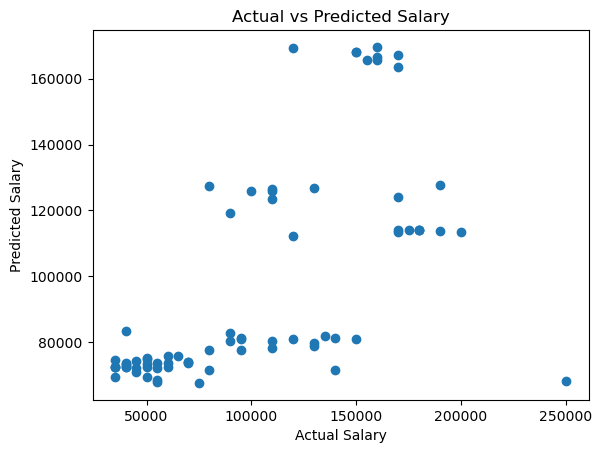

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

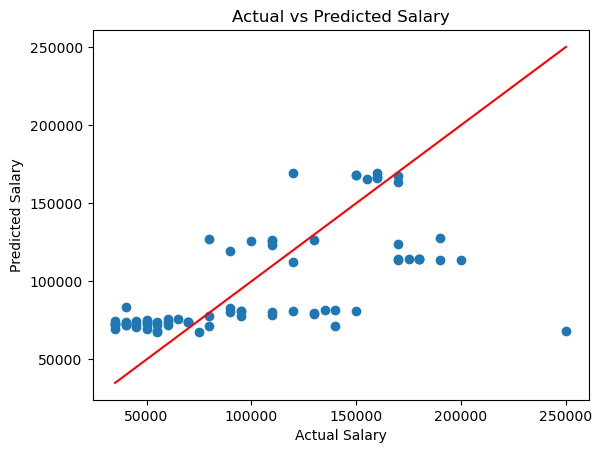

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()